# NB13: LITTLE THINGS BTFR Test — Dwarf Regime Check

**Purpose:** Apply the fixed BTFR trend (slope=0.238, intercept=-12.55 from Paper 2)
to LITTLE THINGS g(Rt) values. Compute residuals, run the Wilcoxon signed-rank test.

This is the **secondary confirmatory test** (dwarf regime). If a0/2 alignment holds
in dwarfs, it's not a massive-galaxy artifact.

**M_bar computation:** Uses Oh et al. (2015) table values (Mgas in 10^7 Msun,
MstarSED/MstarK in 10^7 Msun) rather than SPARC photometry. M_bar = 1.33*Mgas + Mstar.

**Sample:** All LITTLE THINGS galaxies with valid g(Rt) from NB12.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.physics import A0_HALF, ACCEL_TO_MKS
from src.btfr import compute_btfr_residuals, BTFR_ALPHA, BTFR_BETA
from src.ingest import (
    load_little_things_galaxies, compute_mbar_little_things,
)

a0_half_mks = A0_HALF * ACCEL_TO_MKS

results_dir = project_root / "results"
results_dir.mkdir(exist_ok=True)

## 1. Load g(Rt) Results from NB12

In [2]:
diag_df = pd.read_csv(results_dir / "NB12_lt_diagnostics.csv")

# Keep only valid g(Rt)
valid = diag_df[np.isfinite(diag_df["g_Rt_mks"])].copy()

# Extract base name from galaxy_id (strip _LITTLE_THINGS suffix)
valid["base_name"] = valid["galaxy_id"].str.replace("_LITTLE_THINGS", "", regex=False)

print(f"Galaxies with valid g(Rt): {len(valid)}")
for _, r in valid.iterrows():
    print(f"  {r['galaxy_id']:30s}  g = {r['g_Rt_mks']:.4e} m/s^2")

Galaxies with valid g(Rt): 14
  DDO_101_LITTLE_THINGS           g = 1.0068e-10 m/s^2
  DDO_126_LITTLE_THINGS           g = 1.3576e-11 m/s^2
  DDO_133_LITTLE_THINGS           g = 2.6417e-11 m/s^2
  DDO_154_LITTLE_THINGS           g = 2.1151e-11 m/s^2
  DDO_210_LITTLE_THINGS           g = 1.1479e-11 m/s^2
  DDO_216_LITTLE_THINGS           g = 6.5300e-12 m/s^2
  DDO_43_LITTLE_THINGS            g = 1.1457e-11 m/s^2
  DDO_52_LITTLE_THINGS            g = 2.7705e-11 m/s^2
  DDO_70_LITTLE_THINGS            g = 2.7555e-11 m/s^2
  DDO_87_LITTLE_THINGS            g = 1.3716e-11 m/s^2
  IC_10_LITTLE_THINGS             g = 2.6710e-12 m/s^2
  NGC_1569_LITTLE_THINGS          g = 7.2918e-12 m/s^2
  NGC_2366_LITTLE_THINGS          g = 2.1950e-11 m/s^2
  WLM_LITTLE_THINGS               g = 1.9420e-11 m/s^2


## 2. Compute Baryonic Masses

Uses Oh et al. (2015) table values: M_bar = 1.33 * Mgas + Mstar.
Stellar mass preference: MstarSED > MstarK > gas-only.

In [3]:
gal_df = load_little_things_galaxies()

# Build M_bar for each galaxy with valid g(Rt)
mbar_values = {}
mstar_sources = {}

for _, r in valid.iterrows():
    name = r["base_name"]
    meta = gal_df[gal_df["Name"] == name]
    if meta.empty:
        continue
    meta = meta.iloc[0]

    # Choose stellar mass: prefer MstarSED, fallback to MstarK, then gas-only
    if np.isfinite(meta["MstarSED"]):
        mstar = meta["MstarSED"]
        source = "MstarSED"
    elif np.isfinite(meta["MstarK"]):
        mstar = meta["MstarK"]
        source = "MstarK"
    else:
        mstar = np.nan  # gas-only
        source = "gas-only"

    mbar = compute_mbar_little_things(meta["Mgas"], mstar)
    mbar_values[name] = mbar
    mstar_sources[name] = source

valid["M_bar"] = valid["base_name"].map(mbar_values)
valid["Mstar_source"] = valid["base_name"].map(mstar_sources)

print(f"{'Galaxy':30s} {'g(Rt) [m/s^2]':>15s} {'M_bar [Msun]':>15s} {'Source':>10s}")
print("-" * 75)
for _, r in valid.iterrows():
    print(f"{r['galaxy_id']:30s} {r['g_Rt_mks']:15.4e} {r['M_bar']:15.3e} "
          f"{r['Mstar_source']:>10s}")

# Flag gas-dominated galaxies
for _, r in valid.iterrows():
    meta = gal_df[gal_df["Name"] == r["base_name"]].iloc[0]
    m_gas = 1.33 * meta["Mgas"] * 1e7
    gas_frac = m_gas / r["M_bar"] if r["M_bar"] > 0 else np.nan
    if gas_frac > 0.9:
        print(f"  NOTE: {r['base_name']} is gas-dominated (gas fraction = {gas_frac:.1%})")

missing = valid[valid["M_bar"].isna()]
if len(missing) > 0:
    print(f"\nWARNING: {len(missing)} galaxies missing M_bar!")
else:
    print(f"\nAll {len(valid)} galaxies have M_bar values.")

2026-04-09 23:23:17 | INFO     | src.ingest | Loaded 26 LITTLE THINGS galaxies


Galaxy                           g(Rt) [m/s^2]    M_bar [Msun]     Source
---------------------------------------------------------------------------
DDO_101_LITTLE_THINGS               1.0068e-10       1.117e+08   MstarSED
DDO_126_LITTLE_THINGS               1.3576e-11       2.338e+08   MstarSED
DDO_133_LITTLE_THINGS               2.6417e-11       2.013e+08   MstarSED
DDO_154_LITTLE_THINGS               2.1151e-11       4.774e+08   MstarSED
DDO_210_LITTLE_THINGS               1.1479e-11       2.462e+06   MstarSED
DDO_216_LITTLE_THINGS               6.5300e-12       2.162e+07   MstarSED
DDO_43_LITTLE_THINGS                1.1457e-11       3.094e+08   gas-only
DDO_52_LITTLE_THINGS                2.7705e-11       4.977e+08   MstarSED
DDO_70_LITTLE_THINGS                2.7555e-11       7.014e+07   MstarSED
DDO_87_LITTLE_THINGS                1.3716e-11       4.200e+08   MstarSED
IC_10_LITTLE_THINGS                 2.6710e-12       1.400e+08     MstarK
NGC_1569_LITTLE_THINGS              

## 3. Sample Size Check

In [4]:
n_sample = len(valid.dropna(subset=["M_bar", "g_Rt_mks"]))
print(f"Sample size for BTFR test: N = {n_sample}")
print()
if n_sample < 15:
    print(f"WARNING: N < 15. Below pre-registered power threshold.")
    print(f"Wilcoxon test will have reduced power. This will be explicitly documented.")
if n_sample < 6:
    print(f"WARNING: N < 6. Wilcoxon test may not be reliable.")
elif n_sample < 10:
    print(f"NOTE: N < 10. Wilcoxon test has low power; interpret with caution.")

Sample size for BTFR test: N = 14

Wilcoxon test will have reduced power. This will be explicitly documented.


## 4. Raw g(Rt) Summary

In [5]:
g_vals = valid["g_Rt_mks"].dropna().values
m_bar = valid["M_bar"].dropna().values

median_g = np.median(g_vals)
ratio = median_g / a0_half_mks
offset_pct = (ratio - 1) * 100

log_g = np.log10(g_vals)
p16, p84 = np.percentile(log_g, [16, 84])
scatter_raw = (p84 - p16) / 2.0

print("Raw g(Rt) Summary (LITTLE THINGS)")
print("=" * 50)
print(f"  N valid:           {len(g_vals)}")
print(f"  Median g(Rt):      {median_g:.4e} m/s^2")
print(f"  a0/2:              {a0_half_mks:.4e} m/s^2")
print(f"  Ratio:             {ratio:.4f}")
print(f"  Offset from a0/2:  {offset_pct:+.1f}%")
print(f"  Raw scatter (dex): {scatter_raw:.3f}")
print()
within_10pct = abs(offset_pct) <= 10
print(f"  Within +/-10% threshold: {'YES' if within_10pct else 'NO'}")
print(f"  (Paper 2 SPARC: +8.5%, THINGS: +45.6%)")

Raw g(Rt) Summary (LITTLE THINGS)
  N valid:           14
  Median g(Rt):      1.6568e-11 m/s^2
  a0/2:              6.0003e-11 m/s^2
  Ratio:             0.2761
  Offset from a0/2:  -72.4%
  Raw scatter (dex): 0.280

  Within +/-10% threshold: NO
  (Paper 2 SPARC: +8.5%, THINGS: +45.6%)


## 5. BTFR Residuals and Wilcoxon Test

In [6]:
residuals = compute_btfr_residuals(g_vals, m_bar, alpha=BTFR_ALPHA, beta=BTFR_BETA)

p16_r, p84_r = np.percentile(residuals, [16, 84])
scatter_residual = (p84_r - p16_r) / 2.0

print("BTFR Residuals (LITTLE THINGS)")
print("=" * 50)
print(f"  N residuals:       {len(residuals)}")
print(f"  Median residual:   {np.median(residuals):+.4f} dex")
print(f"  Mean residual:     {np.mean(residuals):+.4f} dex")
print(f"  Residual scatter:  {scatter_residual:.3f} dex")
print(f"  Raw scatter:       {scatter_raw:.3f} dex")
print(f"  Scatter reduction: {scatter_raw:.3f} -> {scatter_residual:.3f} dex "
      f"({(1 - scatter_residual/scatter_raw)*100:.0f}% reduction)")
print()
print("Per-galaxy residuals:")
for i, (_, r) in enumerate(valid.iterrows()):
    if i < len(residuals):
        print(f"  {r['galaxy_id']:30s}  dlog_g = {residuals[i]:+.4f}")

# Wilcoxon test
print()
print("Wilcoxon Signed-Rank Test")
print("=" * 50)
nonzero_residuals = residuals[residuals != 0]
n_nonzero = len(nonzero_residuals)
print(f"  N nonzero residuals: {n_nonzero}")

if n_nonzero >= 6:
    stat, pvalue = stats.wilcoxon(nonzero_residuals, alternative="two-sided")
    print(f"  Test statistic:      {stat:.1f}")
    print(f"  p-value:             {pvalue:.4f}")
    print()
    if pvalue < 0.05:
        print("  RESULT: Reject H0 (p < 0.05). Residuals are NOT centered on zero.")
    else:
        print("  RESULT: Cannot reject H0 (p >= 0.05). Residuals are consistent")
        print("  with zero median.")
elif n_nonzero >= 3:
    stat, pvalue = stats.wilcoxon(nonzero_residuals, alternative="two-sided")
    print(f"  WARNING: Low N ({n_nonzero}). Running with extreme caution.")
    print(f"  Test statistic:      {stat:.1f}")
    print(f"  p-value:             {pvalue:.4f}")
else:
    stat, pvalue = np.nan, np.nan
    print(f"  Cannot run test with N < 3.")

BTFR Residuals (LITTLE THINGS)
  N residuals:       14
  Median residual:   -0.2417 dex
  Mean residual:     -0.2081 dex
  Residual scatter:  0.245 dex
  Raw scatter:       0.280 dex
  Scatter reduction: 0.280 -> 0.245 dex (12% reduction)

Per-galaxy residuals:
  DDO_101_LITTLE_THINGS           dlog_g = +0.6375
  DDO_126_LITTLE_THINGS           dlog_g = -0.3090
  DDO_133_LITTLE_THINGS           dlog_g = -0.0044
  DDO_154_LITTLE_THINGS           dlog_g = -0.1902
  DDO_210_LITTLE_THINGS           dlog_g = +0.0888
  DDO_216_LITTLE_THINGS           dlog_g = -0.3808
  DDO_43_LITTLE_THINGS            dlog_g = -0.4116
  DDO_52_LITTLE_THINGS            dlog_g = -0.0773
  DDO_70_LITTLE_THINGS            dlog_g = +0.1229
  DDO_87_LITTLE_THINGS            dlog_g = -0.3651
  IC_10_LITTLE_THINGS             dlog_g = -0.9621
  NGC_1569_LITTLE_THINGS          dlog_g = -0.6817
  NGC_2366_LITTLE_THINGS          dlog_g = -0.2931
  WLM_LITTLE_THINGS               dlog_g = -0.0864

Wilcoxon Signed-Rank Te

## 6. Diagnostic Plots

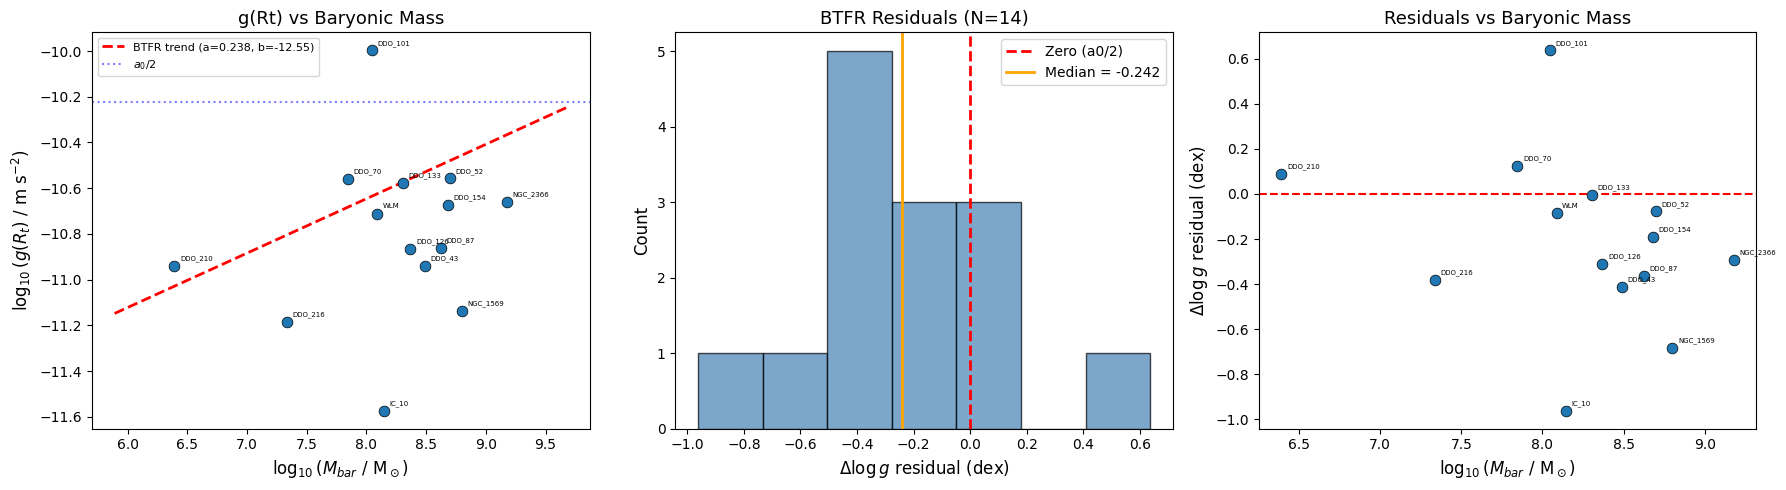

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

log_m = np.log10(m_bar)
log_g_obs = np.log10(g_vals)

# Left: g(Rt) vs M_bar with BTFR trend
ax = axes[0]
m_range = np.linspace(log_m.min() - 0.5, log_m.max() + 0.5, 100)
g_trend = BTFR_ALPHA * m_range + BTFR_BETA
ax.plot(m_range, g_trend, "r--", linewidth=2,
        label=f"BTFR trend (a={BTFR_ALPHA}, b={BTFR_BETA})")
ax.scatter(log_m, log_g_obs, s=60, edgecolors="k", linewidth=0.5, zorder=3)
for i, (_, r) in enumerate(valid.iterrows()):
    ax.annotate(r["base_name"], (log_m[i], log_g_obs[i]),
                fontsize=5, textcoords="offset points", xytext=(4, 4))
ax.axhline(np.log10(a0_half_mks), color="blue", linestyle=":", alpha=0.5,
           label="$a_0/2$")
ax.set_xlabel(r"$\log_{10}(M_{bar}$ / M$_\odot$)", fontsize=12)
ax.set_ylabel(r"$\log_{10}(g(R_t)$ / m s$^{-2}$)", fontsize=12)
ax.set_title("g(Rt) vs Baryonic Mass", fontsize=13)
ax.legend(fontsize=8)

# Center: Residual histogram
ax = axes[1]
ax.hist(residuals, bins=max(5, len(residuals) // 2), edgecolor="black",
        alpha=0.7, color="steelblue")
ax.axvline(0, color="red", linestyle="--", linewidth=2, label="Zero (a0/2)")
ax.axvline(np.median(residuals), color="orange", linestyle="-", linewidth=2,
           label=f"Median = {np.median(residuals):+.3f}")
ax.set_xlabel(r"$\Delta \log g$ residual (dex)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title(f"BTFR Residuals (N={len(residuals)})", fontsize=13)
ax.legend(fontsize=10)

# Right: Residual vs M_bar
ax = axes[2]
ax.scatter(log_m, residuals, s=60, edgecolors="k", linewidth=0.5, zorder=3)
for i, (_, r) in enumerate(valid.iterrows()):
    ax.annotate(r["base_name"], (log_m[i], residuals[i]),
                fontsize=5, textcoords="offset points", xytext=(4, 4))
ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel(r"$\log_{10}(M_{bar}$ / M$_\odot$)", fontsize=12)
ax.set_ylabel(r"$\Delta \log g$ residual (dex)", fontsize=12)
ax.set_title("Residuals vs Baryonic Mass", fontsize=13)

plt.tight_layout()
plt.savefig(results_dir / "NB13_lt_btfr_test.png", dpi=150)
plt.show()

## 7. Three-Dataset Comparison

In [8]:
p_str = f"{pvalue:.3f}" if np.isfinite(pvalue) else "N/A"

print("Cross-Dataset Comparison")
print("=" * 70)
print(f"{'Metric':30s} {'SPARC (NB02)':>14s} {'THINGS (NB09)':>14s} {'LT (NB13)':>14s}")
print("-" * 70)
print(f"{'N resolved':30s} {'98':>14s} {'8':>14s} {len(g_vals):>14d}")
print(f"{'Median g(Rt) [m/s^2]':30s} {'6.51e-11':>14s} {'8.73e-11':>14s} "
      f"{f'{median_g:.2e}':>14s}")
print(f"{'Offset from a0/2':30s} {'+8.5%':>14s} {'+45.6%':>14s} "
      f"{f'{offset_pct:+.1f}%':>14s}")
print(f"{'Raw scatter [dex]':30s} {'0.409':>14s} {'0.346':>14s} "
      f"{f'{scatter_raw:.3f}':>14s}")
print(f"{'BTFR-resid scatter [dex]':30s} {'0.277':>14s} {'0.210':>14s} "
      f"{f'{scatter_residual:.3f}':>14s}")
print(f"{'Median residual [dex]':30s} {'~0 (anchored)':>14s} {'+0.049':>14s} "
      f"{f'{np.median(residuals):+.3f}':>14s}")
print(f"{'Wilcoxon p-value':30s} {'0.654':>14s} {'0.547':>14s} "
      f"{p_str:>14s}")

Cross-Dataset Comparison
Metric                           SPARC (NB02)  THINGS (NB09)      LT (NB13)
----------------------------------------------------------------------
N resolved                                 98              8             14
Median g(Rt) [m/s^2]                 6.51e-11       8.73e-11       1.66e-11
Offset from a0/2                        +8.5%         +45.6%         -72.4%
Raw scatter [dex]                       0.409          0.346          0.280
BTFR-resid scatter [dex]                0.277          0.210          0.245
Median residual [dex]           ~0 (anchored)         +0.049         -0.242
Wilcoxon p-value                        0.654          0.547          0.049


## 8. Outcome Determination

In [9]:
print("OUTCOME DETERMINATION")
print("=" * 60)
print()

within_threshold = abs(offset_pct) <= 10
wilcoxon_sig = np.isfinite(pvalue) and pvalue < 0.05
low_power = len(g_vals) < 15

print(f"  1. Median g(Rt) within +/-10% of a0/2: "
      f"{'YES' if within_threshold else 'NO'} ({offset_pct:+.1f}%)")
print(f"  2. Wilcoxon rejects zero-median:        "
      f"{'YES' if wilcoxon_sig else 'NO'} (p = {p_str})")
print(f"  3. Sample size adequate (N >= 15):      "
      f"{'YES' if not low_power else 'NO'} (N = {len(g_vals)})")
print()

if within_threshold and not wilcoxon_sig:
    outcome = "CONSISTENT"
    print("  OUTCOME: a0/2 alignment is CONSISTENT with LITTLE THINGS data.")
    if low_power:
        print("  CAVEAT: Low statistical power (N < 15).")
elif wilcoxon_sig:
    outcome = "REJECTED"
    print("  OUTCOME: a0/2 alignment REJECTED by LITTLE THINGS data.")
elif not within_threshold and not wilcoxon_sig:
    outcome = "INCONCLUSIVE"
    print("  OUTCOME: INCONCLUSIVE. Median falls outside +/-10% threshold")
    print("  but Wilcoxon does not reject zero-median. Likely underpowered.")
    if low_power:
        print("  Low N compounds the ambiguity.")

print(f"\n  Outcome code: {outcome}")

OUTCOME DETERMINATION

  1. Median g(Rt) within +/-10% of a0/2: NO (-72.4%)
  2. Wilcoxon rejects zero-median:        YES (p = 0.049)
  3. Sample size adequate (N >= 15):      NO (N = 14)

  OUTCOME: a0/2 alignment REJECTED by LITTLE THINGS data.

  Outcome code: REJECTED


## 9. Gate Check and Export

In [10]:
checks = {
    "All valid g(Rt) galaxies have M_bar": not valid["M_bar"].isna().any(),
    "BTFR residuals computed": len(residuals) == len(g_vals),
    "Wilcoxon test executed or documented": np.isfinite(pvalue) or len(g_vals) < 3,
    "Outcome determined": outcome in ["CONSISTENT", "REJECTED", "INCONCLUSIVE"],
}

print("GATE CHECK: NB13 -- LITTLE THINGS BTFR Test")
print("=" * 55)
all_pass = True
for name, passed in checks.items():
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_pass = False
    print(f"  [{status}] {name}")

print()
if all_pass:
    print("  >>> NB13 COMPLETE -- Block 4 finished <<<")
else:
    print("  >>> NB13 has failures -- diagnose <<<")

# Export
results_out = {
    "n_galaxies": len(g_vals),
    "median_g_mks": float(median_g),
    "offset_pct": float(offset_pct),
    "scatter_raw_dex": float(scatter_raw),
    "scatter_residual_dex": float(scatter_residual),
    "median_residual_dex": float(np.median(residuals)),
    "wilcoxon_stat": float(stat) if np.isfinite(stat) else None,
    "wilcoxon_pvalue": float(pvalue) if np.isfinite(pvalue) else None,
    "outcome": outcome,
}
pd.DataFrame([results_out]).to_csv(results_dir / "NB13_lt_btfr_results.csv", index=False)

valid_export = valid.copy()
valid_export["residual"] = residuals
valid_export.to_csv(results_dir / "NB13_lt_per_galaxy.csv", index=False)

print(f"\nResults saved to results/NB13_lt_btfr_results.csv")
print(f"Per-galaxy data saved to results/NB13_lt_per_galaxy.csv")

GATE CHECK: NB13 -- LITTLE THINGS BTFR Test
  [PASS] All valid g(Rt) galaxies have M_bar
  [PASS] BTFR residuals computed
  [PASS] Wilcoxon test executed or documented
  [PASS] Outcome determined

  >>> NB13 COMPLETE -- Block 4 finished <<<

Results saved to results/NB13_lt_btfr_results.csv
Per-galaxy data saved to results/NB13_lt_per_galaxy.csv
